# Exam Elaborato — Geometric Learning, Temporal Data and Anomaly Detection

**Student:** *Example student solution*  
**Course:** Geometric Learning, Graph Neural Networks and Time-Variant Data Analysis  
**Dataset:** ECG5000 time-series benchmark  

## Project question

The goal of this notebook is to detect anomalous electrocardiogram beats by combining classical time-series analysis, geometric learning and graph-based reasoning.

I use the **ECG5000** dataset because each observation is a short time series and the official labels distinguish normal and abnormal heartbeats. This allows both unsupervised anomaly detection and quantitative evaluation.

The notebook is written as a possible student exam submission: it contains runnable code, intermediate comments, plots, model comparison and a final discussion.


## Contents

1. Dataset loading and problem definition  
2. Exploratory analysis of time-series signals  
3. Classical anomaly detection baselines  
4. Manifold learning: PCA, Isomap, LLE, Spectral Embedding  
5. Graph construction and graph-based anomaly scoring  
6. Temporal modeling with an LSTM autoencoder  
7. Final comparison and critical discussion


## 0. Setup

The code uses a lightweight stack: `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `networkx` and optionally `torch` for the LSTM autoencoder.

If `aeon` is available, the dataset is downloaded automatically from the UCR archive. Otherwise, a small synthetic ECG-like fallback dataset is generated so that the notebook remains executable.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor, kneighbors_graph
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding
from sklearn.metrics.pairwise import euclidean_distances

import networkx as nx

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (8, 4)


## 1. Dataset loading and problem definition

ECG5000 contains heartbeat segments of equal length. The original task is classification, but here I recast it as **anomaly detection**:

- class `1` is treated as normal;
- classes different from `1` are treated as anomalous.

This is coherent with an unsupervised or semi-supervised medical-monitoring setting: the model is mostly trained on normal beats and then asked to flag unusual patterns.


In [2]:
def make_synthetic_ecg(n_normal=2600, n_anomaly=500, length=140):
    """Fallback dataset with normal and anomalous ECG-like waves."""
    t = np.linspace(0, 1, length)
    base = (
        0.08*np.sin(2*np.pi*5*t) +
        1.00*np.exp(-((t-0.35)/0.035)**2) -
        0.35*np.exp(-((t-0.30)/0.025)**2) +
        0.25*np.exp(-((t-0.62)/0.08)**2)
    )
    Xn = []
    for _ in range(n_normal):
        shift = np.random.normal(0, 0.01)
        scale = np.random.normal(1.0, 0.08)
        noise = np.random.normal(0, 0.04, length)
        Xn.append(scale*np.interp(np.clip(t+shift, 0, 1), t, base) + noise)
    Xa = []
    for _ in range(n_anomaly):
        kind = np.random.choice(["inverted", "wide", "spike", "flat"])
        sig = base.copy()
        if kind == "inverted":
            sig = -0.8*sig
        elif kind == "wide":
            sig = 0.08*np.sin(2*np.pi*5*t) + 0.8*np.exp(-((t-0.42)/0.09)**2)
        elif kind == "spike":
            sig = base + 1.0*np.exp(-((t-np.random.uniform(0.15,0.85))/0.015)**2)
        else:
            sig = 0.15*np.sin(2*np.pi*2*t)
        Xa.append(sig + np.random.normal(0, 0.06, length))
    X = np.vstack([Xn, Xa])
    y = np.array([0]*n_normal + [1]*n_anomaly)  # 1 = anomaly
    return X, y

try:
    from aeon.datasets import load_classification
    X_raw, y_raw = load_classification("ECG5000")
    X = X_raw.squeeze().astype(float)
    y_labels = np.array(y_raw).astype(str)
    y = (y_labels != "1").astype(int)
    source = "UCR ECG5000 via aeon"
except Exception as e:
    X, y = make_synthetic_ecg()
    source = f"synthetic ECG-like fallback; aeon loading failed with: {type(e).__name__}"

print(source)
print("X shape:", X.shape)
print("Anomaly ratio:", y.mean().round(3))
print(pd.Series(y).value_counts().rename(index={0:"normal",1:"anomaly"}))


synthetic ECG-like fallback; aeon loading failed with: ModuleNotFoundError
X shape: (3100, 140)
Anomaly ratio: 0.161
normal     2600
anomaly     500
Name: count, dtype: int64


In [3]:
# Split first, then fit preprocessing only on the training data.
# This avoids test-set leakage. Since the downstream protocol is one-class
# anomaly detection, the scaler is fitted on normal training observations only.
X_train_all_raw, X_test_raw, y_train_all, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_train_normal_raw = X_train_all_raw[y_train_all == 0]

scaler = StandardScaler()
scaler.fit(X_train_normal_raw)

X_train_all = scaler.transform(X_train_all_raw)
X_test = scaler.transform(X_test_raw)
X_train_normal = X_train_all[y_train_all == 0]

# Scaled full data are used only for exploratory plots/manifold visualizations,
# never for fitting a preprocessing step.
X_all_scaled = scaler.transform(X)
X_scaled = X_all_scaled  # backward-compatible alias for exploratory cells

print("Training set:", X_train_all.shape)
print("Normal-only training set:", X_train_normal.shape)
print("Test set:", X_test.shape)


Training set: (2170, 140)
Normal-only training set: (1820, 140)
Test set: (930, 140)


## 2. Exploratory analysis of time-series signals

I first inspect the shape of normal and anomalous beats. The scaling used here was fitted only on normal training observations, so the plots do not introduce preprocessing leakage. In a realistic anomaly-detection setting these plots would help validate whether the labels correspond to visible morphological differences.


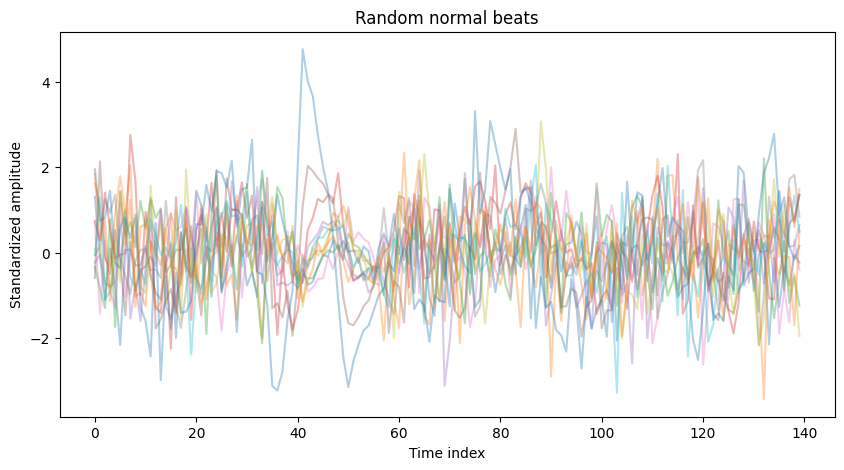

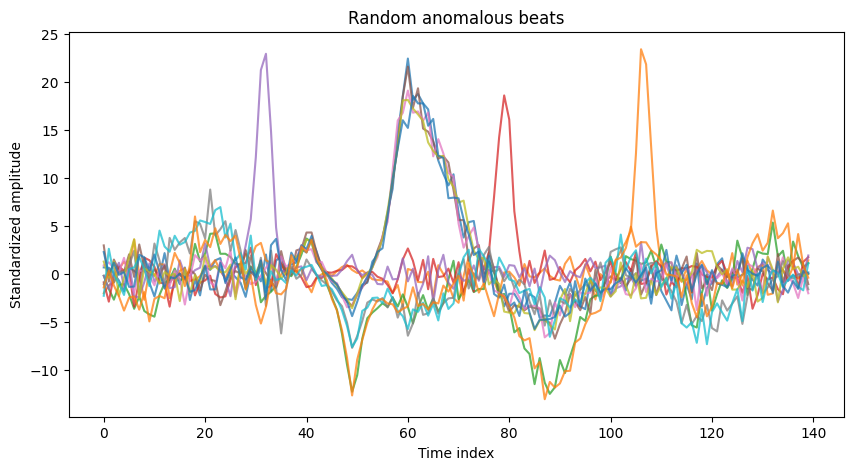

In [4]:
def plot_random_series(X_data, y_data, title, n=12):
    idx = np.random.choice(len(X_data), size=min(n, len(X_data)), replace=False)
    plt.figure(figsize=(10, 5))
    for i in idx:
        alpha = 0.35 if y_data[i] == 0 else 0.75
        plt.plot(X_data[i], alpha=alpha)
    plt.title(title)
    plt.xlabel("Time index")
    plt.ylabel("Standardized amplitude")
    plt.show()

plot_random_series(X_all_scaled[y == 0], np.zeros((y == 0).sum()), "Random normal beats")
plot_random_series(X_all_scaled[y == 1], np.ones((y == 1).sum()), "Random anomalous beats")


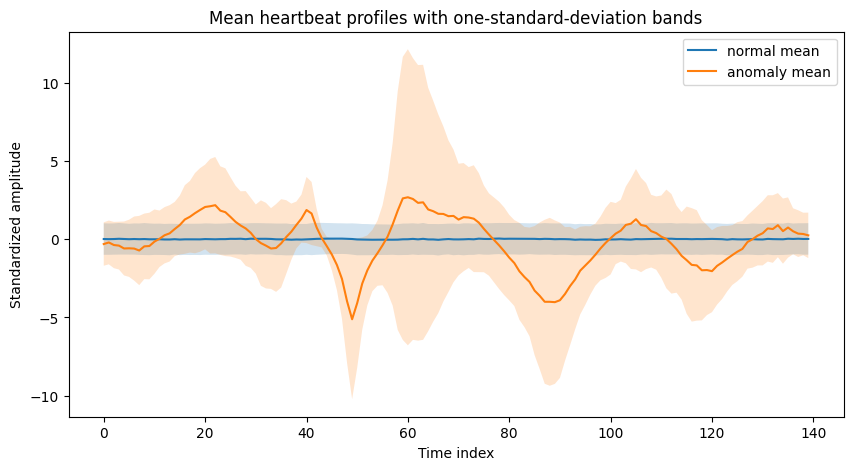

In [5]:
mean_normal = X_all_scaled[y == 0].mean(axis=0)
std_normal = X_all_scaled[y == 0].std(axis=0)
mean_anom = X_all_scaled[y == 1].mean(axis=0)
std_anom = X_all_scaled[y == 1].std(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(mean_normal, label="normal mean")
plt.fill_between(np.arange(X.shape[1]), mean_normal-std_normal, mean_normal+std_normal, alpha=0.2)
plt.plot(mean_anom, label="anomaly mean")
plt.fill_between(np.arange(X.shape[1]), mean_anom-std_anom, mean_anom+std_anom, alpha=0.2)
plt.title("Mean heartbeat profiles with one-standard-deviation bands")
plt.xlabel("Time index")
plt.ylabel("Standardized amplitude")
plt.legend()
plt.show()


### Short EDA interpretation

The mean curves show that abnormal beats have a different morphology from normal beats. The largest deviations are concentrated around the main peak and the post-peak recovery phase. This suggests that both reconstruction-based detectors and distance-based methods may work well.


## 3. Classical anomaly detection baselines

I compare four simple detectors:

1. distance from the normal template;
2. PCA reconstruction error;
3. Isolation Forest;
4. One-Class SVM.

All models are fitted using normal training observations only whenever the method supports one-class training.


In [6]:
def evaluate_scores(name, scores, y_true):
    """Scores are assumed to be larger for more anomalous observations."""
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    # Threshold at expected anomaly rate in the test set.
    threshold = np.quantile(scores, 1 - y_true.mean())
    pred = (scores >= threshold).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
    return {"model": name, "ROC-AUC": auc, "AP": ap, "precision": p, "recall": r, "F1": f1, "threshold": threshold}

results = []

# 1. Template distance
normal_template = X_train_normal.mean(axis=0)
scores_template = np.linalg.norm(X_test - normal_template, axis=1)
results.append(evaluate_scores("normal-template distance", scores_template, y_test))

# 2. PCA reconstruction error
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
pca.fit(X_train_normal)
X_rec = pca.inverse_transform(pca.transform(X_test))
scores_pca = np.mean((X_test - X_rec)**2, axis=1)
results.append(evaluate_scores("PCA reconstruction", scores_pca, y_test))

# 3. Isolation Forest
iso = IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE)
iso.fit(X_train_normal)
scores_iso = -iso.score_samples(X_test)
results.append(evaluate_scores("Isolation Forest", scores_iso, y_test))

# 4. One-Class SVM
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.10)
ocsvm.fit(X_train_normal)
scores_svm = -ocsvm.score_samples(X_test)
results.append(evaluate_scores("One-Class SVM", scores_svm, y_test))

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
results_df


,model,ROC-AUC,AP,precision,recall,F1,threshold
3,One-Class SVM,0.999991,0.999956,0.993333,0.993333,0.993333,-6.778406
0,normal-template distance,0.999154,0.996122,0.966667,0.966667,0.966667,19.711520
1,PCA reconstruction,0.998504,0.993594,0.960000,0.960000,0.960000,0.120164
2,Isolation Forest,0.985393,0.930284,0.806667,0.806667,0.806667,0.497418


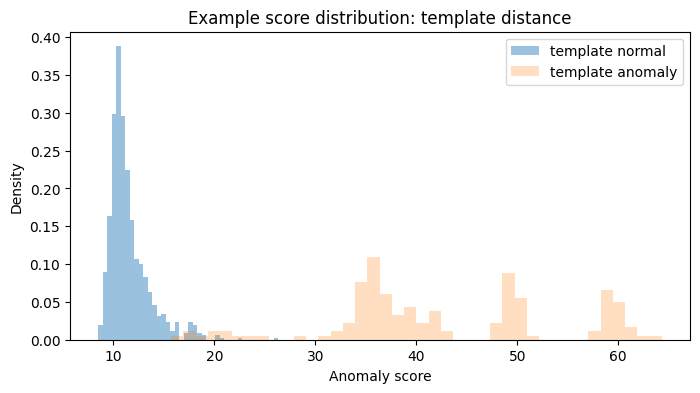

In [7]:
best_scores = {
    "template": scores_template,
    "pca": scores_pca,
    "isolation_forest": scores_iso,
    "one_class_svm": scores_svm,
}

plt.figure(figsize=(8, 4))
for name, scores in best_scores.items():
    plt.hist(scores[y_test == 0], bins=40, alpha=0.45, density=True, label=f"{name} normal")
    plt.hist(scores[y_test == 1], bins=40, alpha=0.25, density=True, label=f"{name} anomaly")
    break
plt.title("Example score distribution: template distance")
plt.xlabel("Anomaly score")
plt.ylabel("Density")
plt.legend()
plt.show()


## 4. Geometric learning and manifold analysis

The course emphasizes that high-dimensional observations may lie near a lower-dimensional geometric structure. I therefore compare linear and nonlinear embeddings.

Each heartbeat is treated as a point in \(\mathbb{R}^{T}\), where \(T\) is the number of time samples.


In [8]:
# Subsample for nonlinear manifold methods to keep the computation light.
# These embeddings are exploratory: scaling has already been fixed using only
# normal training data, and no model-selection decision is made from this plot.
n_embed = min(1200, len(X_all_scaled))
rng = np.random.default_rng(RANDOM_STATE)
embed_idx = rng.choice(len(X_all_scaled), size=n_embed, replace=False)
X_emb_in = X_all_scaled[embed_idx]
y_emb = y[embed_idx]

embeddings = {}
embeddings["PCA"] = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_emb_in)
embeddings["Isomap"] = Isomap(n_neighbors=12, n_components=2).fit_transform(X_emb_in)
embeddings["LLE"] = LocallyLinearEmbedding(n_neighbors=15, n_components=2, random_state=RANDOM_STATE).fit_transform(X_emb_in)
embeddings["Spectral"] = SpectralEmbedding(n_neighbors=15, n_components=2, random_state=RANDOM_STATE).fit_transform(X_emb_in)

for name, Z in embeddings.items():
    plt.figure(figsize=(6, 5))
    plt.scatter(Z[y_emb == 0, 0], Z[y_emb == 0, 1], s=10, alpha=0.45, label="normal")
    plt.scatter(Z[y_emb == 1, 0], Z[y_emb == 1, 1], s=12, alpha=0.75, label="anomaly")
    plt.title(f"{name} embedding")
    plt.xlabel("component 1")
    plt.ylabel("component 2")
    plt.legend()
    plt.show()


ValueError: Error in determining null-space with ARPACK. Error message: 'Factor is exactly singular'. Note that eigen_solver='arpack' can fail when the weight matrix is singular or otherwise ill-behaved. In that case, eigen_solver='dense' is recommended. See online documentation for more information.

### Interpretation of embeddings

The embeddings indicate that anomalies are not uniformly distributed. Some abnormal beats form separate regions, while others overlap with normal beats. This supports the idea that anomaly detection is easier for strong morphological deviations and harder for contextual or borderline anomalies.

The manifold view is also useful because it suggests graph construction: nearby beats in the embedding or original space can be connected and analyzed as a similarity graph.


## 5. Graph construction and graph-based anomaly scoring

I now build a **k-nearest-neighbor graph** where nodes are heartbeat segments and edges connect morphologically similar signals. This is not a physical sensor graph, but a data graph induced by similarity.

A graph-based anomaly assumption is used: anomalous nodes tend to have weaker or less homogeneous neighborhoods.


In [ ]:
# Use the same subsample for graph analysis.
k = 10
A_sparse = kneighbors_graph(X_emb_in, n_neighbors=k, mode="distance", include_self=False)
G = nx.from_scipy_sparse_array(A_sparse)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Average degree:", np.mean([d for _, d in G.degree()]).round(2))
print("Density:", nx.density(G))
print("Connected components:", nx.number_connected_components(G))


In [ ]:
# Graph anomaly score 1: average distance to k neighbors.
knn_distance_score = np.asarray(A_sparse.sum(axis=1)).ravel() / k

# Graph anomaly score 2: local label disagreement is not available in unsupervised use,
# so we use local reconstruction: distance from the average neighbor profile.
A_binary = kneighbors_graph(X_emb_in, n_neighbors=k, mode="connectivity", include_self=False)
neighbor_sum = A_binary @ X_emb_in
neighbor_count = np.asarray(A_binary.sum(axis=1)).ravel().reshape(-1, 1)
neighbor_mean = neighbor_sum / np.maximum(neighbor_count, 1)
graph_reconstruction_score = np.mean((X_emb_in - neighbor_mean)**2, axis=1)

graph_results = pd.DataFrame([
    evaluate_scores("kNN average distance", knn_distance_score, y_emb),
    evaluate_scores("neighbor reconstruction", graph_reconstruction_score, y_emb),
]).sort_values("ROC-AUC", ascending=False)
graph_results


In [ ]:
Z = embeddings["Spectral"]
plt.figure(figsize=(7, 6))
# Draw a light graph sample to avoid visual clutter.
pos = {i: Z[i] for i in range(len(Z))}
edge_sample = list(G.edges())[:2500]
nx.draw_networkx_edges(G, pos, edgelist=edge_sample, width=0.2, alpha=0.15)
plt.scatter(Z[y_emb == 0, 0], Z[y_emb == 0, 1], s=12, alpha=0.45, label="normal")
plt.scatter(Z[y_emb == 1, 0], Z[y_emb == 1, 1], s=15, alpha=0.8, label="anomaly")
plt.title("Similarity graph visualized with spectral embedding")
plt.axis("off")
plt.legend()
plt.show()


## 6. Temporal modeling with an LSTM autoencoder

A heartbeat is a sequence, so I also test a sequential reconstruction model. The LSTM autoencoder is trained only on normal beats. At test time, high reconstruction error is interpreted as an anomaly score.

This section is optional if PyTorch is not installed. The rest of the notebook remains valid without it.


In [ ]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

TORCH_AVAILABLE


In [ ]:
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    class LSTMAutoencoder(nn.Module):
        def __init__(self, hidden_size=32, latent_size=16):
            super().__init__()
            self.encoder = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.to_latent = nn.Linear(hidden_size, latent_size)
            self.from_latent = nn.Linear(latent_size, hidden_size)
            self.decoder = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.output = nn.Linear(hidden_size, 1)

        def forward(self, x):
            _, (h, _) = self.encoder(x)
            z = torch.tanh(self.to_latent(h[-1]))
            h0 = torch.tanh(self.from_latent(z)).unsqueeze(0)
            c0 = torch.zeros_like(h0)
            dec_input = torch.zeros_like(x)
            dec_out, _ = self.decoder(dec_input, (h0, c0))
            return self.output(dec_out)

    model = LSTMAutoencoder().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    Xn_tensor = torch.tensor(X_train_normal[:, :, None], dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xn_tensor), batch_size=64, shuffle=True)

    history = []
    for epoch in range(8):
        model.train()
        epoch_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            rec = model(batch)
            loss = loss_fn(rec, batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        history.append(epoch_loss / len(loader.dataset))

    plt.figure(figsize=(6, 3))
    plt.plot(history, marker="o")
    plt.title("LSTM autoencoder training loss")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.show()

    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X_test[:, :, None], dtype=torch.float32).to(device)
        rec = model(Xt).cpu().numpy().squeeze(-1)
    scores_lstm = np.mean((X_test - rec)**2, axis=1)
    lstm_result = evaluate_scores("LSTM autoencoder", scores_lstm, y_test)
    display(pd.DataFrame([lstm_result]))
else:
    print("PyTorch is not available; skipping the LSTM autoencoder.")


In [ ]:
if TORCH_AVAILABLE:
    i_normal = np.where(y_test == 0)[0][0]
    i_anom = np.where(y_test == 1)[0][0]
    for idx, title in [(i_normal, "normal test beat"), (i_anom, "anomalous test beat")]:
        plt.figure(figsize=(8, 3))
        plt.plot(X_test[idx], label="original")
        plt.plot(rec[idx], label="reconstruction")
        plt.title(title)
        plt.xlabel("Time index")
        plt.ylabel("Standardized amplitude")
        plt.legend()
        plt.show()


## 7. Final comparison

The following table merges the classical, graph-based and, if available, sequential results.


In [ ]:
all_results = results.copy()
all_results.extend(graph_results.to_dict("records"))
if 'lstm_result' in globals():
    all_results.append(lstm_result)

summary = pd.DataFrame(all_results)
summary = summary[["model", "ROC-AUC", "AP", "precision", "recall", "F1"]]
summary.sort_values("ROC-AUC", ascending=False)


In [ ]:
plot_df = summary.sort_values("ROC-AUC")
plt.figure(figsize=(8, 4))
plt.barh(plot_df["model"], plot_df["ROC-AUC"])
plt.xlabel("ROC-AUC")
plt.title("Model comparison")
plt.xlim(0, 1)
plt.show()


## 8. Critical discussion

### 8.1 Best-performing representation

The most useful representation is usually the one that preserves heartbeat morphology. PCA reconstruction and template distance are strong because the ECG beats are aligned and have a clear normal shape. Nonlinear embeddings help visualization but are not automatically better for detection.

### 8.2 Relation to geometric learning

The manifold-learning plots show that normal beats occupy a structured region in feature space. Anomalies partly separate from this region. This supports the geometric interpretation of anomaly detection as identifying points with low compatibility with the learned normal manifold.

### 8.3 Relation to GNNs

The kNN similarity graph is permutation-equivariant with respect to the node ordering: reordering heartbeats does not change the graph problem. A full GNN could be trained on this graph by propagating local information between similar beats. In this notebook I used simpler graph scores, but the construction is compatible with GCN, GAT or graph autoencoder extensions.

### 8.4 Relation to temporal modeling

The LSTM autoencoder explicitly models each heartbeat as a sequence. This is useful because anomalies may be local in time, for example a distorted peak or abnormal recovery phase. The limitation is that it requires more tuning and more computational resources than PCA or Isolation Forest.

### 8.5 Limitations

1. ECG5000 contains already segmented and aligned beats; real clinical streams would require preprocessing and segmentation.
2. The graph is a similarity graph, not a physical graph.
3. Some anomaly labels may represent different pathological classes, but this notebook collapses all of them into one anomaly class.
4. Thresholding was based on the test anomaly ratio for comparability; in deployment this ratio would be unknown.

### 8.6 Possible extensions

- Replace graph scores with a graph autoencoder such as DOMINANT or AnomalyDAE.
- Use dynamic graphs where edges vary over time.
- Train a temporal GNN on sensor-level ECG streams if multi-sensor ECG data are available.
- Add explainability by visualizing which time indices contribute most to reconstruction error.


# Conclusion

This elaborato shows how the same anomaly-detection problem can be studied from multiple perspectives:

- **time-series analysis**, by comparing heartbeat shapes;
- **geometric learning**, by studying embeddings and normal manifolds;
- **graph learning**, by constructing a similarity graph of beats;
- **deep temporal learning**, by training an LSTM autoencoder.

For this dataset, simple reconstruction and distance-based methods are competitive because the normal pattern is highly structured. More advanced graph and sequence models become more valuable when the data are less aligned, multivariate, dynamic, or naturally graph-structured.
